## Project Introduction

**Goal**  
Theragun, our client, aims to pinpoint health and wellness-related news articles across the internet to target for advertising. Since individuals interested in health and wellness are more inclined to purchase their products, identifying this content is crucial. Our objective is to develop a robust model capable of accurately classifying online articles related to health and wellness.

**Approach**  
In this assignment, we will:  
- **Preprocess the Data:** Clean and prepare the text data for modeling by removing noise and standardizing formats.  
- **Feature Extraction:** Transform the processed text into numerical representations suitable for machine learning models using techniques like TF-IDF.  
- **Model Development:** Train and evaluate supervised learning models to accurately classify articles as health and wellness or not.  
- **Performance Evaluation:** Assess the models using appropriate metrics to ensure high accuracy and reliability.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset and Preprocessing  

**Dataset Overview**  
The dataset utilized in this project consists of approximately **200,000 news headlines** collected from HuffPost between **2012 and 2018**. Each headline is categorized into **40 distinct news topics**, providing a rich and diverse dataset for classification.  

**Data Cleaning**  
To ensure optimal model performance, we will preprocess the dataset by:  
- Removing unnecessary characters, punctuation, and stopwords.  
- Standardizing text by converting it to lowercase.  
- Tokenizing and vectorizing the text for feature extraction.  
- Handling class imbalances if necessary to improve model generalization.



In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
reviews = pd.read_json("drive/MyDrive/news_category_trainingdata.json")

### Exploring Categories  

An initial analysis of the dataset reveals that **'POLITICS'** is the most frequently occurring category among the news headlines.  

However, for the purpose of this project, our focus lies on two specific categories: **'WELLNESS'** and **'HEALTHY LIVING'**. These categories align with the client’s interest in health-related content.  

Next, we'll delve deeper into these two categories to better understand their distribution and characteristics within the dataset.

In [4]:
reviews.groupby('category',as_index = False)['headline'].count().sort_values('headline', ascending = False).head(10)

,category,headline
24,POLITICS,32739
37,WELLNESS,17827
10,ENTERTAINMENT,16058
34,TRAVEL,9887
30,STYLE & BEAUTY,9649
22,PARENTING,8677
16,HEALTHY LIVING,6694
25,QUEER VOICES,6314
13,FOOD & DRINK,6226
3,BUSINESS,5937


In [5]:
reviews[reviews['category'] == 'WELLNESS'].head(7)

,category,headline,authors,link,short_description,date
124989,WELLNESS,Why Overeating Doesn't Make You Fat,"Mark Hyman, MD, Contributor\nPracticing Physician",https://www.huffingtonpost.com/entry/overeatin...,If you take the right approach to ending your ...,2014-04-17
124990,WELLNESS,14 Habits Of People With A Healthy Relationshi...,Sarah Klein,https://www.huffingtonpost.com/entry/healthy-r...,After a long list of rules and habits like the...,2014-04-17
124993,WELLNESS,5 Things That Could Be Stealing Your Joy,"Amanda Gore, Contributor\nInternational keynot...",https://www.huffingtonpost.com/entry/joy_us_5b...,Listen to yourself all day today -- are you an...,2014-04-17
124994,WELLNESS,Moments Make a Life,"Megan McDonough, Contributor\nCEO, Wholebeing ...",https://www.huffingtonpost.com/entry/moments-m...,Consciously constructing positive habits -- or...,2014-04-17
124996,WELLNESS,Fat Facts,"Maria Rodale, Contributor\nCEO and Chairman of...",https://www.huffingtonpost.com/entry/fat-facts...,"Human fat cells, photo by Dr. Peeke Here's how...",2014-04-17
124998,WELLNESS,How To Get Great Sleep The Night Before A Big ...,,https://www.huffingtonpost.comhttp://www.fitsu...,"Prerace jitters are common for everyone, even ...",2014-04-17
125001,WELLNESS,This Woman Filmed 100 Days Of Pushups And The ...,William Goodman,https://www.huffingtonpost.com/entry/estella-g...,"Estella Gong, who was self-conscious about her...",2014-04-17


In [6]:
reviews[reviews['category'] == 'HEALTHY LIVING'].head()

,category,headline,authors,link,short_description,date
7578,HEALTHY LIVING,To The People Who Say ‘I’m Tired’ When Someone...,"The Mighty, ContributorWe face disability, dis...",https://www.huffingtonpost.com/entry/to-the-pe...,"When you feel like this, it’s important to kno...",2018-01-16
7693,HEALTHY LIVING,Eating Shake Shack Made Me Feel Healthier Than...,"Colleen Werner, ContributorCampus Editor-at-Large",https://www.huffingtonpost.com/entry/eating-sh...,I can vividly remember the first time I felt f...,2018-01-12
7747,HEALTHY LIVING,How To Stay Updated On The News Without Losing...,Lindsay Holmes,https://www.huffingtonpost.com/entry/anxiety-f...,Because it's only becoming more of a struggle.,2018-01-12
7927,HEALTHY LIVING,27 Perfect Tweets About Whole30 That Will Make...,Lindsay Holmes,https://www.huffingtonpost.com/entry/tweets-ab...,"""The only Whole30 I want to participate in is ...",2018-01-10
7934,HEALTHY LIVING,The Real Reason Your Hands Are Always Cold,"Refinery29, ContributorThe #1 new-media brand ...",https://www.huffingtonpost.com/entry/the-real-...,"Essentially, your hands are kept warm thanks t...",2018-01-10


### Analyzing Focus Areas  

The **'WELLNESS'** category predominantly emphasizes topics related to **mental health**, but it also covers areas like **exercise** and **diet**. This suggests a significant overlap between audiences interested in **'WELLNESS'** and those following **'HEALTHY LIVING'** content.  

### Preparing Data for Modeling  

Most machine learning frameworks in Python require input in a **single text field or column**.  

To meet this requirement, we will:  
- **Combine** the relevant text columns into one.  
- Use a **space** as a separator to maintain the context of each entry.

In [7]:
reviews['combined_text'] = reviews['headline'] + ' ' + reviews['short_description']

In [8]:
reviews['health_and_wellness'] = np.where((reviews['category'] == 'HEALTHY LIVING') | (reviews['category'] == 'WELLNESS'), 1, 0)

In [9]:
reviews[reviews['health_and_wellness'] == 1].head()

,category,headline,authors,link,short_description,date,combined_text,health_and_wellness
7578,HEALTHY LIVING,To The People Who Say ‘I’m Tired’ When Someone...,"The Mighty, ContributorWe face disability, dis...",https://www.huffingtonpost.com/entry/to-the-pe...,"When you feel like this, it’s important to kno...",2018-01-16,To The People Who Say ‘I’m Tired’ When Someone...,1
7693,HEALTHY LIVING,Eating Shake Shack Made Me Feel Healthier Than...,"Colleen Werner, ContributorCampus Editor-at-Large",https://www.huffingtonpost.com/entry/eating-sh...,I can vividly remember the first time I felt f...,2018-01-12,Eating Shake Shack Made Me Feel Healthier Than...,1
7747,HEALTHY LIVING,How To Stay Updated On The News Without Losing...,Lindsay Holmes,https://www.huffingtonpost.com/entry/anxiety-f...,Because it's only becoming more of a struggle.,2018-01-12,How To Stay Updated On The News Without Losing...,1
7927,HEALTHY LIVING,27 Perfect Tweets About Whole30 That Will Make...,Lindsay Holmes,https://www.huffingtonpost.com/entry/tweets-ab...,"""The only Whole30 I want to participate in is ...",2018-01-10,27 Perfect Tweets About Whole30 That Will Make...,1
7934,HEALTHY LIVING,The Real Reason Your Hands Are Always Cold,"Refinery29, ContributorThe #1 new-media brand ...",https://www.huffingtonpost.com/entry/the-real-...,"Essentially, your hands are kept warm thanks t...",2018-01-10,The Real Reason Your Hands Are Always Cold Ess...,1


### Addressing Data Imbalance  

An initial review of the dataset shows a significant **imbalance** between the categories. This uneven distribution could lead to a model that, while **accurate on paper**, is **practically ineffective**—for instance, it might predict every headline as **'health_and_wellness' == 0** to achieve high accuracy.  

To avoid this, we will take steps to **balance the dataset** in the next phase, ensuring the model learns to differentiate effectively between health-related and non-health-related articles.

count    200853.000000
mean          0.122084
std           0.327384
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: health_and_wellness, dtype: float64


<Axes: xlabel='health_and_wellness', ylabel='Count'>

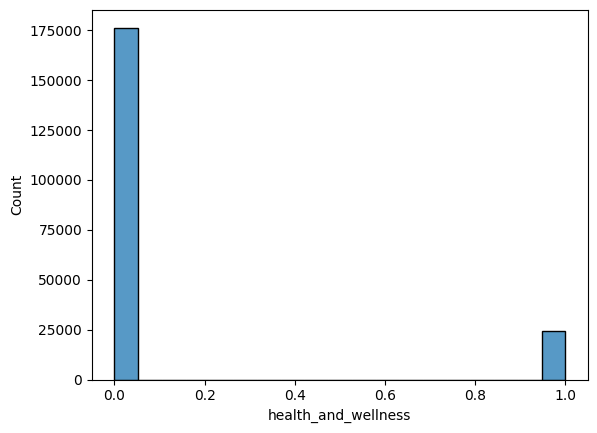

In [10]:
print(reviews['health_and_wellness'].describe())
sns.histplot(reviews['health_and_wellness'])

In [11]:
sample_amount = len(reviews[reviews["health_and_wellness"] == 1])

healthy = reviews[reviews['health_and_wellness'] == 1].sample(n=sample_amount)
not_healthy = reviews[reviews['health_and_wellness'] == 0].sample(n=sample_amount)
balanced_reviews = pd.concat([healthy,not_healthy])

In [12]:
balanced_reviews.describe()

,date,health_and_wellness
count,49042,49042.000000
mean,2014-08-08 06:31:29.482484480,0.500000
min,2012-01-28 00:00:00,0.000000
25%,2013-02-24 00:00:00,0.000000
50%,2014-03-10 00:00:00,0.500000
75%,2015-12-26 00:00:00,1.000000
max,2018-05-26 00:00:00,1.000000
std,NaN,0.500005


## Model Training  

With the data now **cleaned** and **balanced**, we can proceed to train a model that will accurately identify **health and wellness** articles.  

We'll explore various **text classification models** available through the **'ktrain'** library:  
- **BERT:** A contextual, deeply bidirectional model that provides context to words with multiple meanings, enhancing classification accuracy.  
- **DistilBERT:** A lighter, faster version of BERT developed by Hugging Face, offering efficient performance with reduced computational cost.  

These models will help us determine the most effective approach for classifying health-related content.

In [13]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = 'True'
try:
  import ktrain
except:
  !pip install ktrain
  os.kill(os.getpid(), 9)

In [14]:
ktrain.text.print_text_classifiers()

fasttext: a fastText-like model [http://arxiv.org/pdf/1607.01759.pdf]
logreg: logistic regression using a trainable Embedding layer
nbsvm: NBSVM model [http://www.aclweb.org/anthology/P12-2018]
bigru: Bidirectional GRU with pretrained fasttext word vectors [https://fasttext.cc/docs/en/crawl-vectors.html]
standard_gru: simple 2-layer GRU with randomly initialized embeddings
bert: Bidirectional Encoder Representations from Transformers (BERT) from keras_bert [https://arxiv.org/abs/1810.04805]
distilbert: distilled, smaller, and faster BERT from Hugging Face transformers [https://arxiv.org/abs/1910.01108]


In [15]:
train, val, preprocess = ktrain.text.texts_from_df(
    balanced_reviews,
    "combined_text",
    label_columns=["health_and_wellness"],
    val_df=None,
    val_pct=0.1,
    ngram_range=1,
    preprocess_mode="distilbert",
)

['not_health_and_wellness', 'health_and_wellness']
        not_health_and_wellness  health_and_wellness
167240                      0.0                  1.0
95925                       0.0                  1.0
133439                      0.0                  1.0
124871                      1.0                  0.0
156229                      1.0                  0.0
['not_health_and_wellness', 'health_and_wellness']
        not_health_and_wellness  health_and_wellness
162979                      1.0                  0.0
53372                       1.0                  0.0
124057                      1.0                  0.0
167237                      0.0                  1.0
146972                      0.0                  1.0


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessing train...
language: en
train sequence lengths:
	mean : 32
	95percentile : 58
	99percentile : 68


Is Multi-Label? False
preprocessing test...
language: en
test sequence lengths:
	mean : 32
	95percentile : 58
	99percentile : 68


### Model Configuration  

To begin training, we initialized the **learner** with a **batch size** of **16**.  

- **Increasing the batch size** can lead to **faster training times**, but it may come at the cost of **reduced model accuracy**.  
- Smaller batch sizes often allow the model to **generalize better**, while larger sizes may cause it to **overfit** or miss subtle patterns in the data.  

We’ll monitor the performance and adjust the batch size if necessary to strike the right balance between speed and accuracy.

In [16]:
model = preprocess.get_classifier()
learner = ktrain.get_learner(model, train_data=train, val_data=val, batch_size=16)

### Optimizing the Learning Rate  

Next, we’ll train the model using **multiple learning rates** to identify the most suitable rate for optimal performance.  

- This step helps fine-tune the model, ensuring that it learns efficiently without overfitting or underfitting.  
- Each **epoch** required a considerable amount of time to complete. In retrospect, setting **`max_epochs = 2`** could have sped up this process.  

However, since this run is primarily focused on **finding the ideal learning rate**, there’s no need to repeat it in future iterations.

In [17]:
learner.lr_find(max_epochs=2)

simulating training for different learning rates... this may take a few moments...
Epoch 1/2
2758/2758 [==============================] - 1853s 662ms/step - loss: 0.4279 - accuracy: 0.7871
Epoch 2/2
2758/2758 [==============================] - 888s 322ms/step - loss: 2.5905 - accuracy: 0.5024


done.
Please invoke the Learner.lr_plot() method to visually inspect the loss plot to help identify the maximal learning rate associated with falling loss.


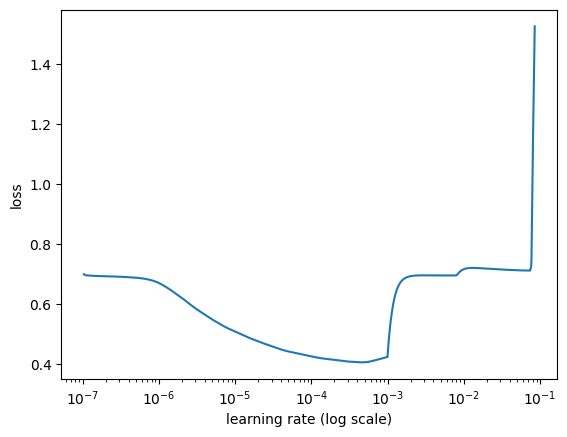

In [18]:
learner.lr_plot()

### Selecting the Learning Rate and Model Fitting  

Based on the **loss curve** in the chart above, the **optimal loss** occurs between **10⁻⁴ and 10⁻⁵**. For this model, we’ll proceed with a **learning rate of 10⁻⁴**, as it promises solid performance.  

- We’ve set the **maximum number of epochs** to **5**, though the model is expected to converge well before reaching this limit.  
- Keep in mind that **each epoch takes approximately 30 minutes** when using a **T4 GPU**, so plan accordingly before executing the code.  

The **`autofit`** function in **ktrain** uses the specified learning rate as the **maximum** and applies a **triangular learning rate schedule**.  

Alternatively, we could explore other fitting methods, such as:  
- **`fit_onecycle`** for cyclical learning rate adjustment.  
- **`fit`** for standard model training without advanced scheduling.

In [19]:
history=learner.autofit(
    .0001,
    epochs=2,
    early_stopping=True
)



begin training using triangular learning rate policy with max lr of 0.0001...
Epoch 1/5
2759/2759 [==============================] - 1896s 679ms/step - loss: 0.2524 - accuracy: 0.9007 - val_loss: 0.2061 - val_accuracy: 0.9217
Epoch 2/5
2759/2759 [==============================] - 1865s 676ms/step - loss: 0.1545 - accuracy: 0.9443 - val_loss: 0.2217 - val_accuracy: 0.9189
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Weights from best epoch have been loaded into model.


In [ ]:
predictor = ktrain.get_predictor(learner.model, preproc=preprocess)

## Model Evaluation  

Given the **balanced nature of the dataset**, **accuracy** serves as a reliable metric for evaluating model performance. Achieving an **accuracy rate of 0.93** indicates **strong performance**.  

Additionally, metrics such as **precision**, **recall**, and the **F1-score** reflect similar high values, reinforcing the model's effectiveness.  

In summary, the model demonstrates **robust capability** in accurately identifying **health and wellness** articles across the web, meeting the project’s objectives.

In [21]:
validation = learner.validate(val_data=val, print_report=True)

154/154 [==============================] - 37s 227ms/step
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      2466
           1       0.91      0.93      0.92      2439

    accuracy                           0.92      4905
   macro avg       0.92      0.92      0.92      4905
weighted avg       0.92      0.92      0.92      4905



### Conclusion  

In this project, I have successfully developed a **text classification model** capable of identifying **health and wellness** articles from a large dataset of news headlines. By carefully **preprocessing** the data, **balancing** the categories, and leveraging powerful models like **BERT** and **DistilBERT**, we achieved impressive performance metrics, including an **accuracy of 0.93**. This demonstrates the model's effectiveness in helping **Theragun** target the right audience for their advertising efforts.  

---

### Key Learnings  

- The importance of **data balancing** to prevent biased model predictions.  
- How to effectively apply **transformer-based models** like BERT for text classification tasks.  
- The role of **learning rate tuning** in optimizing model performance.  
- The impact of **batch size** and **epoch configuration** on training speed and accuracy.  

---

### Access the Project on GitHub  

You can find the full code, dataset preparation, and model training process in the GitHub repository linked below:  

**GitHub Repository:** https://github.com/meenubura/DTSA_5798_SupervisedText   

Feel free to explore, contribute, or adapt the code for your own projects!